<h1 style="text-align:center;"><b>Employee Wellness Analysis</b></h1>

<h2 style="text-align:center;"><b>EDA Project</b></h2>

### DATA LOADING 

In [1]:
import pandas as pd
df = pd.read_csv("employee_wellness_dataset.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   S.No                       1048 non-null   int64 
 1   Timestamp                  1048 non-null   object
 2   Age                        1048 non-null   int64 
 3   Gender                     1048 non-null   object
 4   Country                    1048 non-null   object
 5   state                      636 non-null    object
 6   self_employed              1030 non-null   object
 7   family_history             1048 non-null   object
 8   treatment                  1048 non-null   object
 9   work_interfere             812 non-null    object
 10  no_employees               1048 non-null   object
 11  remote_work                1048 non-null   object
 12  tech_company               1048 non-null   object
 13  benefits                   1035 non-null   object
 14  care_opt

In [3]:
df.head()

,S.No,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,1,8/27/2014 11:29,37,Female,United States,IL,NaN,No,Yes,Often,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2,8/27/2014 11:29,44,M,United States,IN,NaN,No,No,Rarely,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,3,8/27/2014 11:29,32,Male,Canada,NaN,NaN,No,No,Rarely,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,4,8/27/2014 11:29,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,5,8/27/2014 11:30,31,Male,United States,TX,NaN,No,No,Never,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [4]:
df.tail()

,S.No,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
1043,1044,8/29/2014 11:20,26,Male,United States,WA,No,No,Yes,Sometimes,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,NaN
1044,1045,8/29/2014 11:22,29,f,United Kingdom,NaN,No,No,Yes,Often,...,Don't know,Maybe,No,Some of them,No,No,Yes,No,Yes,NaN
1045,1046,8/29/2014 11:23,26,Female,Canada,NaN,No,Yes,Yes,Sometimes,...,Don't know,Maybe,No,Some of them,No,No,Maybe,Don't know,No,NaN
1046,1047,8/29/2014 11:24,33,Malr,Italy,NaN,No,Yes,Yes,Sometimes,...,Somewhat easy,No,No,Some of them,Yes,No,No,Don't know,No,I suffered of panic attacks and agoraphobia fo...
1047,1048,8/29/2014 11:25,28,Male,Brazil,NaN,No,Yes,No,Sometimes,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,Yes,NaN


In [5]:
df.describe()

,S.No,Age
count,1048.000000,1.048000e+03
mean,524.500000,9.541988e+07
std,302.675844,3.089010e+09
min,1.000000,-1.726000e+03
25%,262.750000,2.700000e+01
50%,524.500000,3.100000e+01
75%,786.250000,3.600000e+01
max,1048.000000,1.000000e+11


In [6]:
df.isnull().sum()

S.No                           0
Timestamp                      0
Age                            0
Gender                         0
Country                        0
state                        412
self_employed                 18
family_history                 0
treatment                      0
work_interfere               236
no_employees                   0
remote_work                    0
tech_company                   0
benefits                      13
care_options                   0
wellness_program               4
seek_help                      0
anonymity                      0
leave                          4
mental_health_consequence      0
phys_health_consequence        0
coworkers                      0
supervisor                     0
mental_health_interview        0
phys_health_interview          0
mental_vs_physical             0
obs_consequence                0
comments                     916
dtype: int64

# DATA CLEANING AND PRE-PROCESSING

In [7]:
df.drop(columns=['S.No', 'comments', 'state', 'Timestamp', 'Country', 'no_employees'], inplace=True)

## **STEP 1 — Drop Irrelevant Columns**

### These are dropped because
#### S.No → just a serial number, no analytical value
#### comments → 916/1048 are NaN (87% empty), useless at scale
#### state → 412 NaN (mostly non-US respondents), too sparse to use
#### Timestamp → 3-day survey window (Aug 27-29, 2014), no temporal insight relevant to the problem statement
#### Country → 644/1048 respondents are from US, too skewed to draw meaningful global comparisons
#### No of employees → Not actually needed according to our problem statement.

## **STEP 2 — Fix Age (Handling Outliners using Box Plot)**

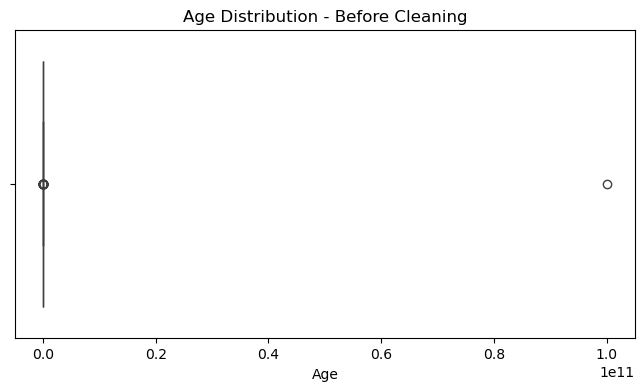

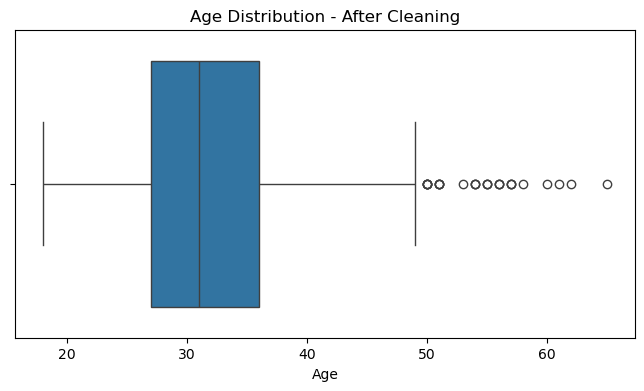

Min    : 18
Q1     : 27.0
Median : 31.0
Q3     : 36.0
Max    : 65
IQR    : 9.0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot BEFORE cleaning
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Age'])
plt.title('Age Distribution - Before Cleaning')
plt.show()

# Values outside = data entry errors, and we are replacing them with the median
# Boolean Indexing is used.
median_age = df[(df['Age'] >= 18) & (df['Age'] <= 65)]['Age'].median()
df['Age'] = df['Age'].apply(lambda x: median_age if x < 18 or x > 65 else x)
df['Age'] = df['Age'].astype(int)

# Boxplot AFTER cleaning
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Age'])
plt.title('Age Distribution - After Cleaning')
plt.show()

# To get quantiles
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

print("Min    :", df['Age'].min())
print("Q1     :", Q1)
print("Median :", df['Age'].median())
print("Q3     :", Q3)
print("Max    :", df['Age'].max())
print("IQR    :", Q3 - Q1) #Inter Quartile Range

#### **Observation:** Before cleaning, the boxplot showed an extreme outlier at 99999999999 making the entire scale go to 1e11. 
#### After cleaning, all 6 invalid age entries (-29, -1726, 5, 8, 329, 99999999999) were replaced with the median age of valid employees. 
#### The verification confirms no values exist outside the 18–65 range. 
#### The dots visible in the after plot are valid ages (58–65) that naturally fall at the edge of the distribution — not outliers.

#### **Important Note**- The dots beyond age 50 are statistically flagged by the 1.5×IQR rule but are NOT data errors 
#### — they represent valid senior employees. The dataset is young-skewed with most employees aged between 27 and 36.

## **Step 3 — Standardize Gender Column**

#### The Gender column has 45 unique entries due to free-text input — including typos, variations, and informal descriptions. 
#### We standardize all values into three categories: Male, Female, and Other using a custom mapping function.

In [9]:
male_terms = ['male', 'm', 'male-ish', 'maile', 'cis male', 'mal', 
              'male (cis)', 'make', 'male ', 'msle', 'malr', 'mail',
              'man', 'guy (-ish) ^_^', 'male leaning androgynous']

female_terms = ['female', 'f', 'woman', 'cis female', 'femake', 
                'female ', 'female (cis)', 'cis-female/femme', 
                'female (trans)', 'femail', 'trans-female', 'trans woman']

other_terms = ['non-binary', 'queer/she/they', 'enby', 'fluid', 
               'genderqueer', 'androgyne', 'agender', 'neuter',
               'something kinda male?', 'queer', 'nah', 'all', 'a little about you']

def clean_gender(g):
    g = str(g).strip().lower()
    if g in male_terms:
        return 'Male'
    elif g in female_terms:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

#### **Observation:** Gender column has been successfully cleaned from 45 unique values down to 3 standardized categories 
#### — Male, Female, and Other — making it ready for analysis and visualization.

In [33]:
print(df["Gender"].value_counts())

Gender
Male      827
Female    206
Other      13
Name: count, dtype: int64


## **STEP 4 — Handle Null Values**

#### Filling the null values using IMPUTATIONS
#### 1. self_employed     → 18 nulls  → Filled with 'No'
#### 2. work_interfere    → 236 nulls → Filled with 'Not Applicable'
#### 3. benefits          → 13 nulls  → Filled with "Don't Know"
#### 4. wellness_program  → 4 nulls   → Filled with "Don't Know"
#### 5. leave             → 4 nulls   → Filled with "Don't Know"

In [10]:
df['self_employed'] = df['self_employed'].fillna('No')
df['work_interfere'] = df['work_interfere'].fillna('Not Applicable')
df['benefits'] = df['benefits'].fillna("Don't Know")
df['wellness_program'] = df['wellness_program'].fillna("Don't Know")
df['leave'] = df['leave'].fillna("Don't Know")

## **STEP 5 — Lowercase Standardization**

In [11]:
# Apply lowercase to all object columns EXCEPT Gender (already clean)
all_col = df.select_dtypes(include='object').columns.tolist()
all_col.remove('Gender')# keep Gender as-is

for col in all_col:
    df[col] = df[col].str.strip().str.lower()

#### **Observation:** All text columns (except Gender) have been standardized to 
#### lowercase with no leading or trailing whitespace, ensuring consistency 
#### for grouping and analysis operations

## **STEP 6 — Checking Duplicates & Final Verification**

In [12]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
df.head()

Duplicate rows: 2
(1046, 22)
Age                          0
Gender                       0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64
Age                           int64
Gender                       object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
remote_work                  object
tech_company            

,Age,Gender,self_employed,family_history,treatment,work_interfere,remote_work,tech_company,benefits,care_options,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,no,no,yes,often,no,yes,yes,not sure,...,yes,somewhat easy,no,no,some of them,yes,no,maybe,yes,no
1,44,Male,no,no,no,rarely,no,no,don't know,no,...,don't know,don't know,maybe,no,no,no,no,no,don't know,no
2,32,Male,no,no,no,rarely,no,yes,no,no,...,don't know,somewhat difficult,no,no,yes,yes,yes,yes,no,no
3,31,Male,no,yes,yes,often,no,yes,no,yes,...,no,somewhat difficult,yes,yes,some of them,no,maybe,maybe,no,yes
4,31,Male,no,no,no,never,yes,yes,yes,no,...,don't know,don't know,no,no,some of them,yes,yes,yes,don't know,no


# Data Cleaning Summary

### A dedicated preprocessing step was carried out before the analysis to ensure that the dataset was clean, consistent, and suitable for reliable interpretation.

#### The following actions were performed:

##### - Removed irrelevant columns such as `S.No`, `comments`,`Timestamp`, `Country`, `no_employees` and `state`.
##### - Corrected 6 invalid entries in the `Age` column.
##### - Standardized the `Gender` column into the categories `Male`, `Female`, and `Other`. 
##### - Treated missing values in the relevant columns using suitable replacements.
##### - Converted text-based columns to a consistent lowercase format after trimming unnecessary spaces.

#### After these steps, the dataset became more structured and analysis-ready, reducing noise and improving the quality of the insights derived.

# **PROBLEM STATEMENT**

## Which workplace support gaps, stigma-related factors and work interference patterns are most associated with employees reporting a need for mental health treatment?

# **Building KPIs**

## **KPI 1 — Employer Support Index**

#### Measures how much support the company provides. Higher = better support.

In [35]:
# Encode support columns: Yes=1, No=0, Don't Know=0.5
supp_index = {'yes': 1, 'no': 0, "don't know": 0.5}

df['benefits_score'] = df['benefits'].map(supp_index)
df['wellness_score'] = df['wellness_program'].map(supp_index)
df['seek_help_score'] = df['seek_help'].map(supp_index)
df['anonymity_score'] = df['anonymity'].map(supp_index)

# Average of all 4 = Employer Support Index (0 to 1)
df['employer_support_index']  = (df['benefits_score'] + df['wellness_score'] + df['seek_help_score'] + df['anonymity_score']) / 4
print(df['employer_support_index'].describe())

count    1046.000000
mean        0.443834
std         0.272789
min         0.000000
25%         0.250000
50%         0.375000
75%         0.625000
max         1.000000
Name: employer_support_index, dtype: float64


###### mean  = 0.44 → average company provides only 44% of possible support
###### min   = 0.00 → some employees get absolutely zero support
###### 50%   = 0.375→ half of all employees score below 0.375 — majority have poor support
###### max   = 1.00 → some lucky employees get full support on all 4 factors
###### std   = 0.27 → wide variation — support quality differs hugely company to company

## **KPI 2 — Workplace Interference Score**

#### Measures how much mental health affects work productivity.

In [14]:
interference_map = {'often': 3,'sometimes': 2,'rarely': 1,'never': 0,'not applicable': 0}
df['interference_score'] = df['work_interfere'].map(interference_map)
print(df['interference_score'].value_counts())
# interference_score is an ordinal encoded column

interference_score
0    414
2    386
1    143
3    103
Name: count, dtype: int64


## **KPI 3 — Stigma Index**

#### Measures fear of negative consequences for discussing mental health. Higher = more stigma.

In [15]:
# mental_health_consequence: Yes=1 (high stigma), Maybe=0.5, No=0
stigma_map = {'yes': 1, 'maybe': 0.5, 'no': 0}
obs_map = {'yes': 1, 'no': 0}
df['mh_stigma_score']  = df['mental_health_consequence'].map(stigma_map)
df['obs_stigma_score'] = df['obs_consequence'].map(obs_map)

# Average = overall Stigma Index
df['stigma_index'] = (df['mh_stigma_score'] + df['obs_stigma_score']) / 2
print(df['stigma_index'].describe())

count    1046.000000
mean        0.276769
std         0.292450
min         0.000000
25%         0.000000
50%         0.250000
75%         0.500000
max         1.000000
Name: stigma_index, dtype: float64


75% of employees score 0.50 or below — but the top 25% with scores above 0.50 are your most at-risk group who are likely avoiding treatment due to fear.

#### Note: Disclosure comfort with coworkers and supervisors represents social-level stigma and is tracked separately as 
#### 'disclosure_comfort_score'.Physical health consequence is intentionally excluded from the stigma index and 
#### reserved for comparative bivariate analysis against mental health stigma — to measure the stigma gap between the two.

## **KPI 4 — Disclosure Comfort Score**

#### Measures how comfortable employees are talking about mental health at work.

In [16]:
disclosure_map = {'yes': 1, 'some of them': 0.5, 'no': 0}

df['coworker_comfort']   = df['coworkers'].map(disclosure_map)
df['supervisor_comfort'] = df['supervisor'].map(disclosure_map)

# Average of both
df['disclosure_comfort_score'] = (df['coworker_comfort'] + df['supervisor_comfort']) / 2
print(df['disclosure_comfort_score'].describe())

count    1046.000000
mean        0.523662
std         0.325329
min         0.000000
25%         0.250000
50%         0.500000
75%         0.750000
max         1.000000
Name: disclosure_comfort_score, dtype: float64


###### mean = median = 0.50 → workforce is equally split between 
###### comfortable and uncomfortable — no dominant pattern, 
###### comfort depends entirely on individual company culture

## **KPI 5 — Leave Accessibility Score**

#### Measures how easy it is to take mental health leave.

In [36]:
leave_map = {'very easy': 4,'somewhat easy': 3, "don't know": 2, 'somewhat difficult': 1, 'very difficult': 0}

df['leave_accessibility_score'] = df['leave'].map(leave_map)
print(df['leave_accessibility_score'].describe())

count    1046.000000
mean        2.286807
std         1.100656
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: leave_accessibility_score, dtype: float64


##### Median = 2.0 ("don't know") but 75% = 3.0 ("somewhat easy") → 
##### The dominance of "Don't Know" responses suggests employees are unaware of leave policies — 
##### tThehe barrier is not access but communication. 
##### Many employees may need support simply to know how to request mental health leave.

## **KPI 6 — Family Risk Flag**

#### Measure of mental illness in family history

In [18]:
# Family Risk Flag: Yes=1, No=0
df['family_risk_flag'] = df['family_history'].map({'yes': 1, 'no': 0})

print(df['family_risk_flag'].value_counts())

family_risk_flag
0    643
1    403
Name: count, dtype: int64


# DATA VISUALIZATION AND GAINING INSIGHTS 

# 1. Univariate Analysis

## Univariate Analysis Using Bar Plots — Categorical Columns 

#### Analyzing the distribution of each categorical column individually to understand the baseline spread of our data before 
#### KPI engineering and comparing against the target variable "Treatment".

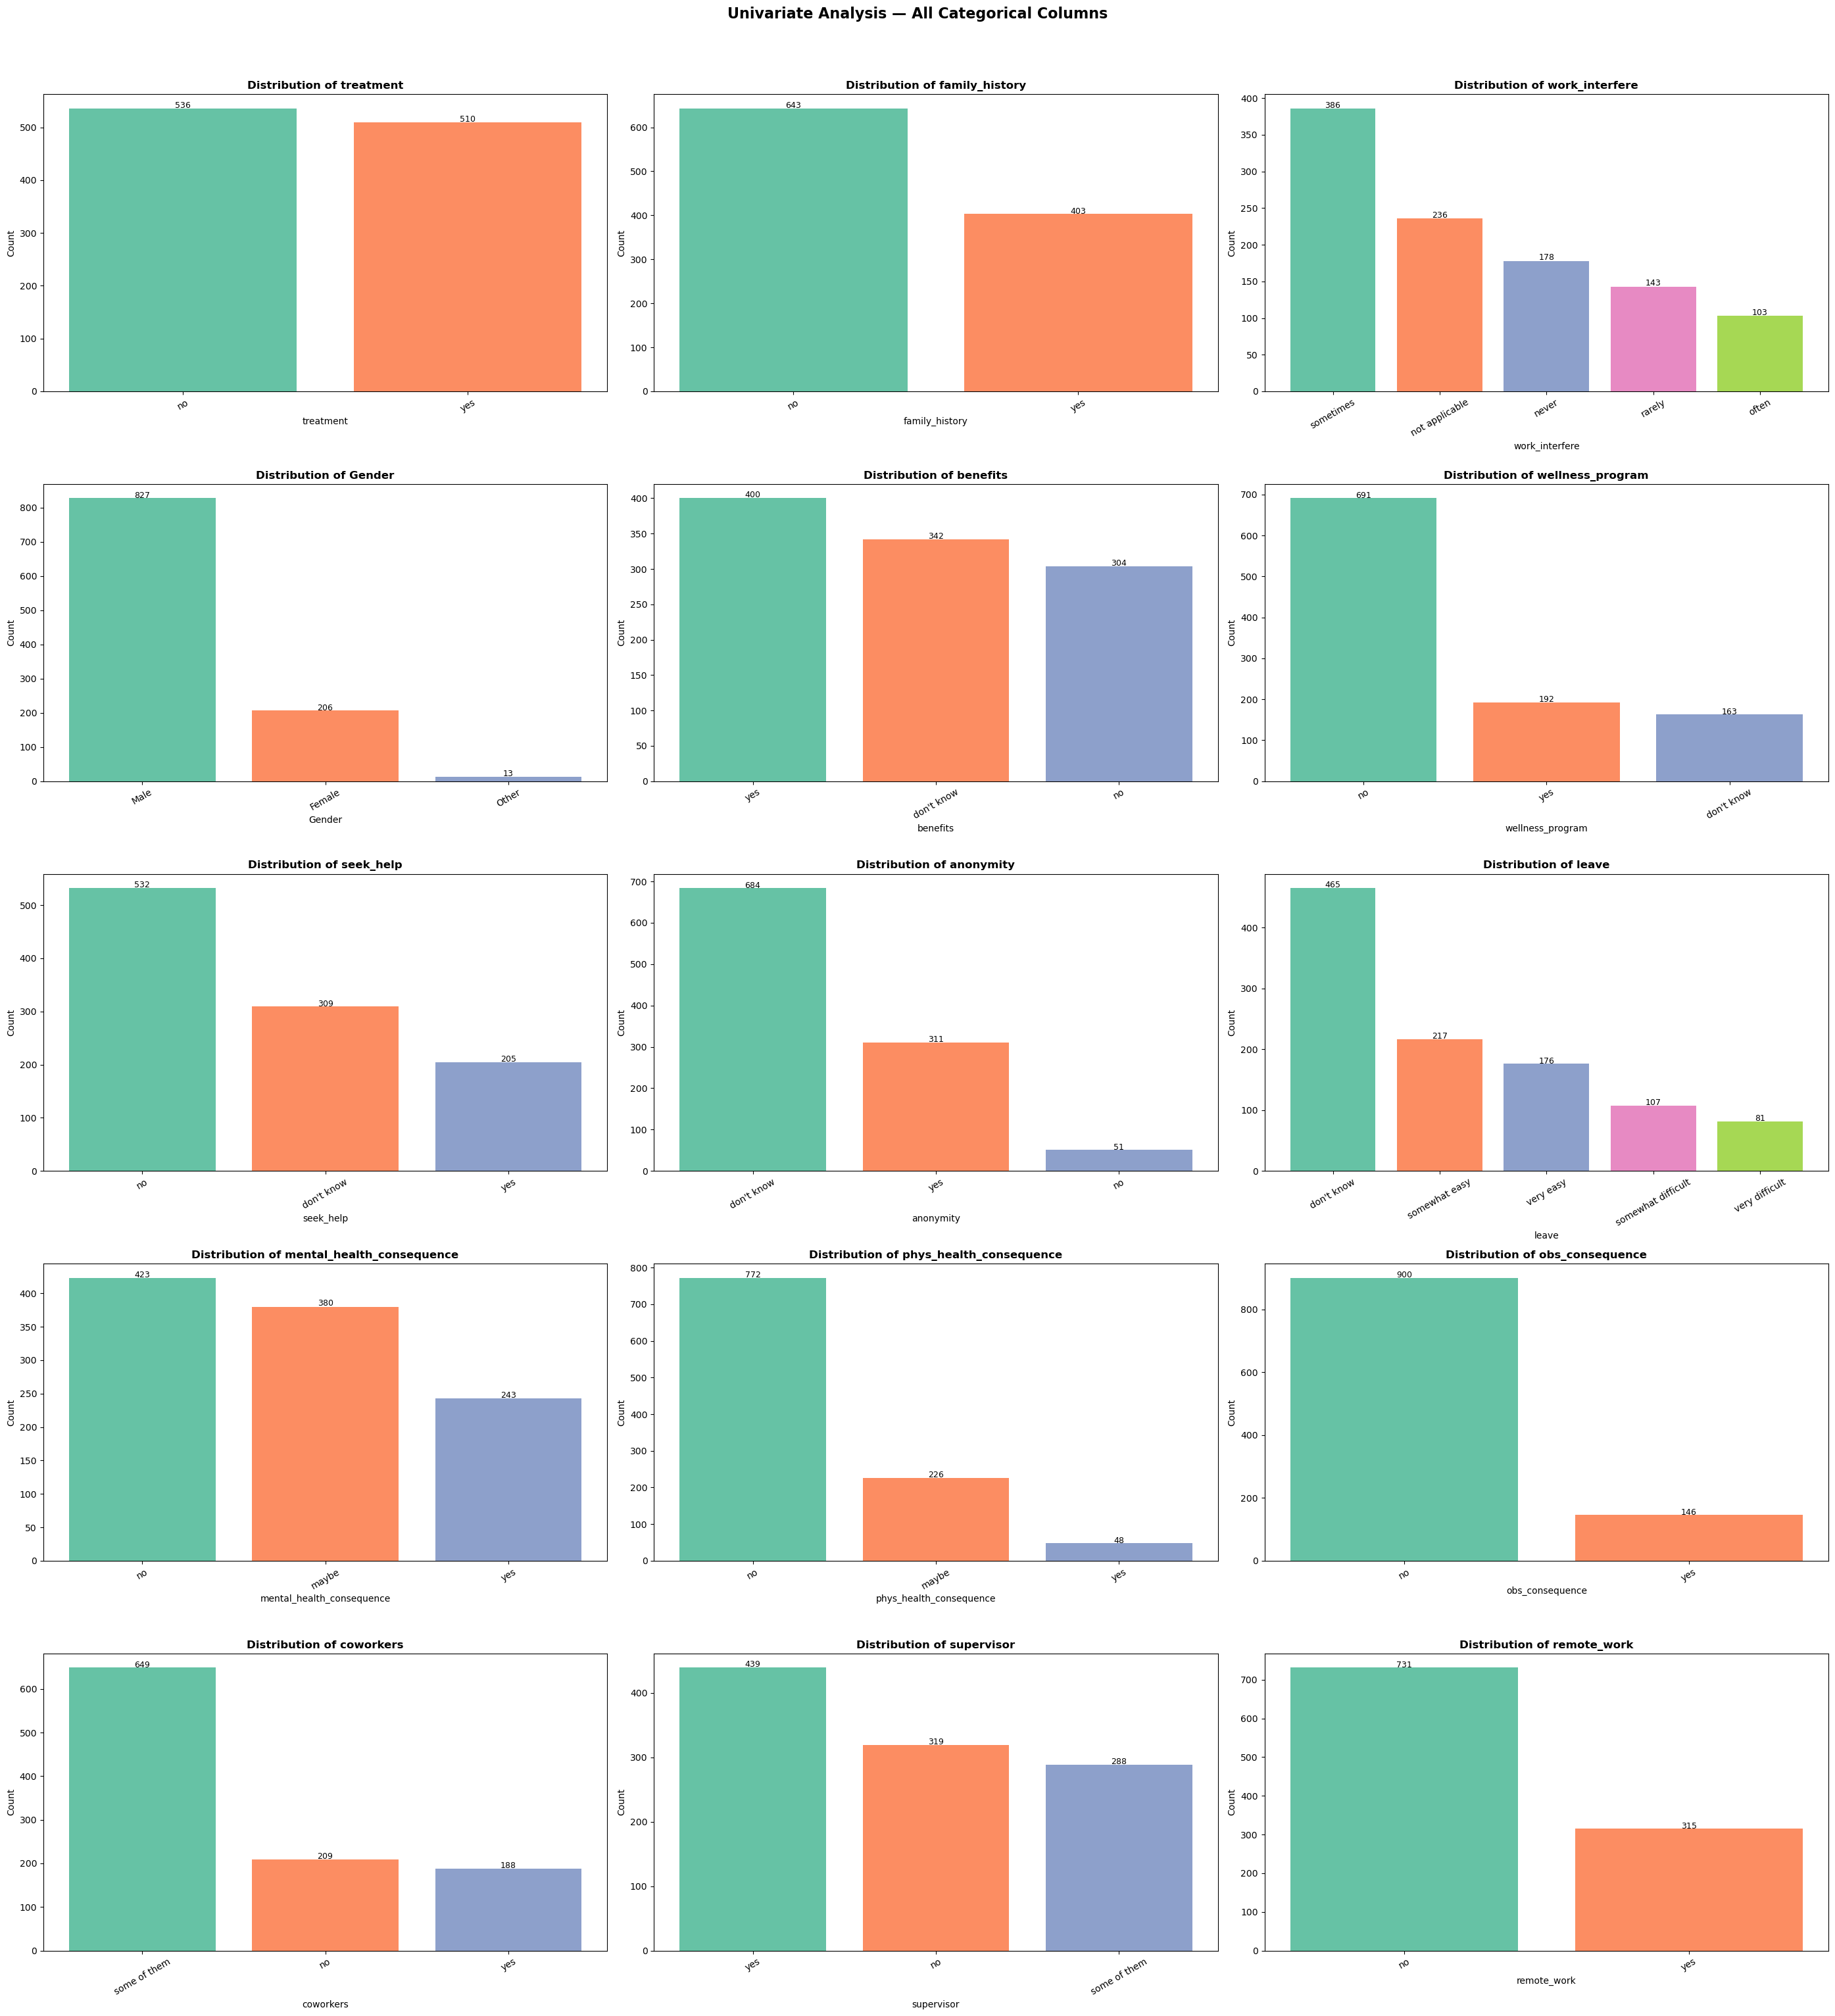

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# All categorical columns to plot
cat_cols = ['treatment', 'family_history', 'work_interfere', 'Gender',
            'benefits', 'wellness_program', 'seek_help', 'anonymity',
            'leave', 'mental_health_consequence', 'phys_health_consequence',
            'obs_consequence', 'coworkers', 'supervisor', 'remote_work']

# Grid setup - 3 columns, auto rows
n_cols = 3
n_rows = (len(cat_cols) // n_cols)  # ceiling division

# Change this line only
fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, n_rows * 6))
axes = axes.flatten()  # convert 2D array to 1D for easy looping

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values, color=sns.color_palette("Set2", len(value_counts)))
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)

    # Print count on top of each bar
    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=9)

# Hide empty subplots if any
for k in range(i + 1, len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Univariate Analysis — All Categorical Columns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [40]:

print("UNIVARIATE INSIGHTS — CATEGORICAL COLUMNS")

for col in cat_cols:
    vc = df[col].value_counts()
    total = vc.sum()
    top_val = vc.index[0]
    top_pct = round((vc.values[0] / total) * 100, 1)
    
    print(f"\n* {col.upper()}")
    print(f"   Most common value : '{top_val}' ({top_pct}%)")
    for val, count in vc.items():
        print(f"   {val:20s} → {count} ({round(count/total*100,1)}%)")

UNIVARIATE INSIGHTS — CATEGORICAL COLUMNS

* TREATMENT
   Most common value : 'no' (51.2%)
   no                   → 536 (51.2%)
   yes                  → 510 (48.8%)

* FAMILY_HISTORY
   Most common value : 'no' (61.5%)
   no                   → 643 (61.5%)
   yes                  → 403 (38.5%)

* WORK_INTERFERE
   Most common value : 'sometimes' (36.9%)
   sometimes            → 386 (36.9%)
   not applicable       → 236 (22.6%)
   never                → 178 (17.0%)
   rarely               → 143 (13.7%)
   often                → 103 (9.8%)

* GENDER
   Most common value : 'Male' (79.1%)
   Male                 → 827 (79.1%)
   Female               → 206 (19.7%)
   Other                → 13 (1.2%)

* BENEFITS
   Most common value : 'yes' (38.2%)
   yes                  → 400 (38.2%)
   don't know           → 342 (32.7%)
   no                   → 304 (29.1%)

* WELLNESS_PROGRAM
   Most common value : 'no' (66.1%)
   no                   → 691 (66.1%)
   yes                  → 192 (18.4%

#### **Observation:** Most employees work in companies with moderate employer support. Treatment need is nearly evenly split. 
#### Family history and work interference show significant presence, indicating both biological and workplace 
#### factors are active in this dataset.

## **Univariate Analysis Using Histogram Plots — Numerical & KPI Columns**

#### Analyzing the distribution of all KPI scores. The red dashed line in each histogram represents the mean value.

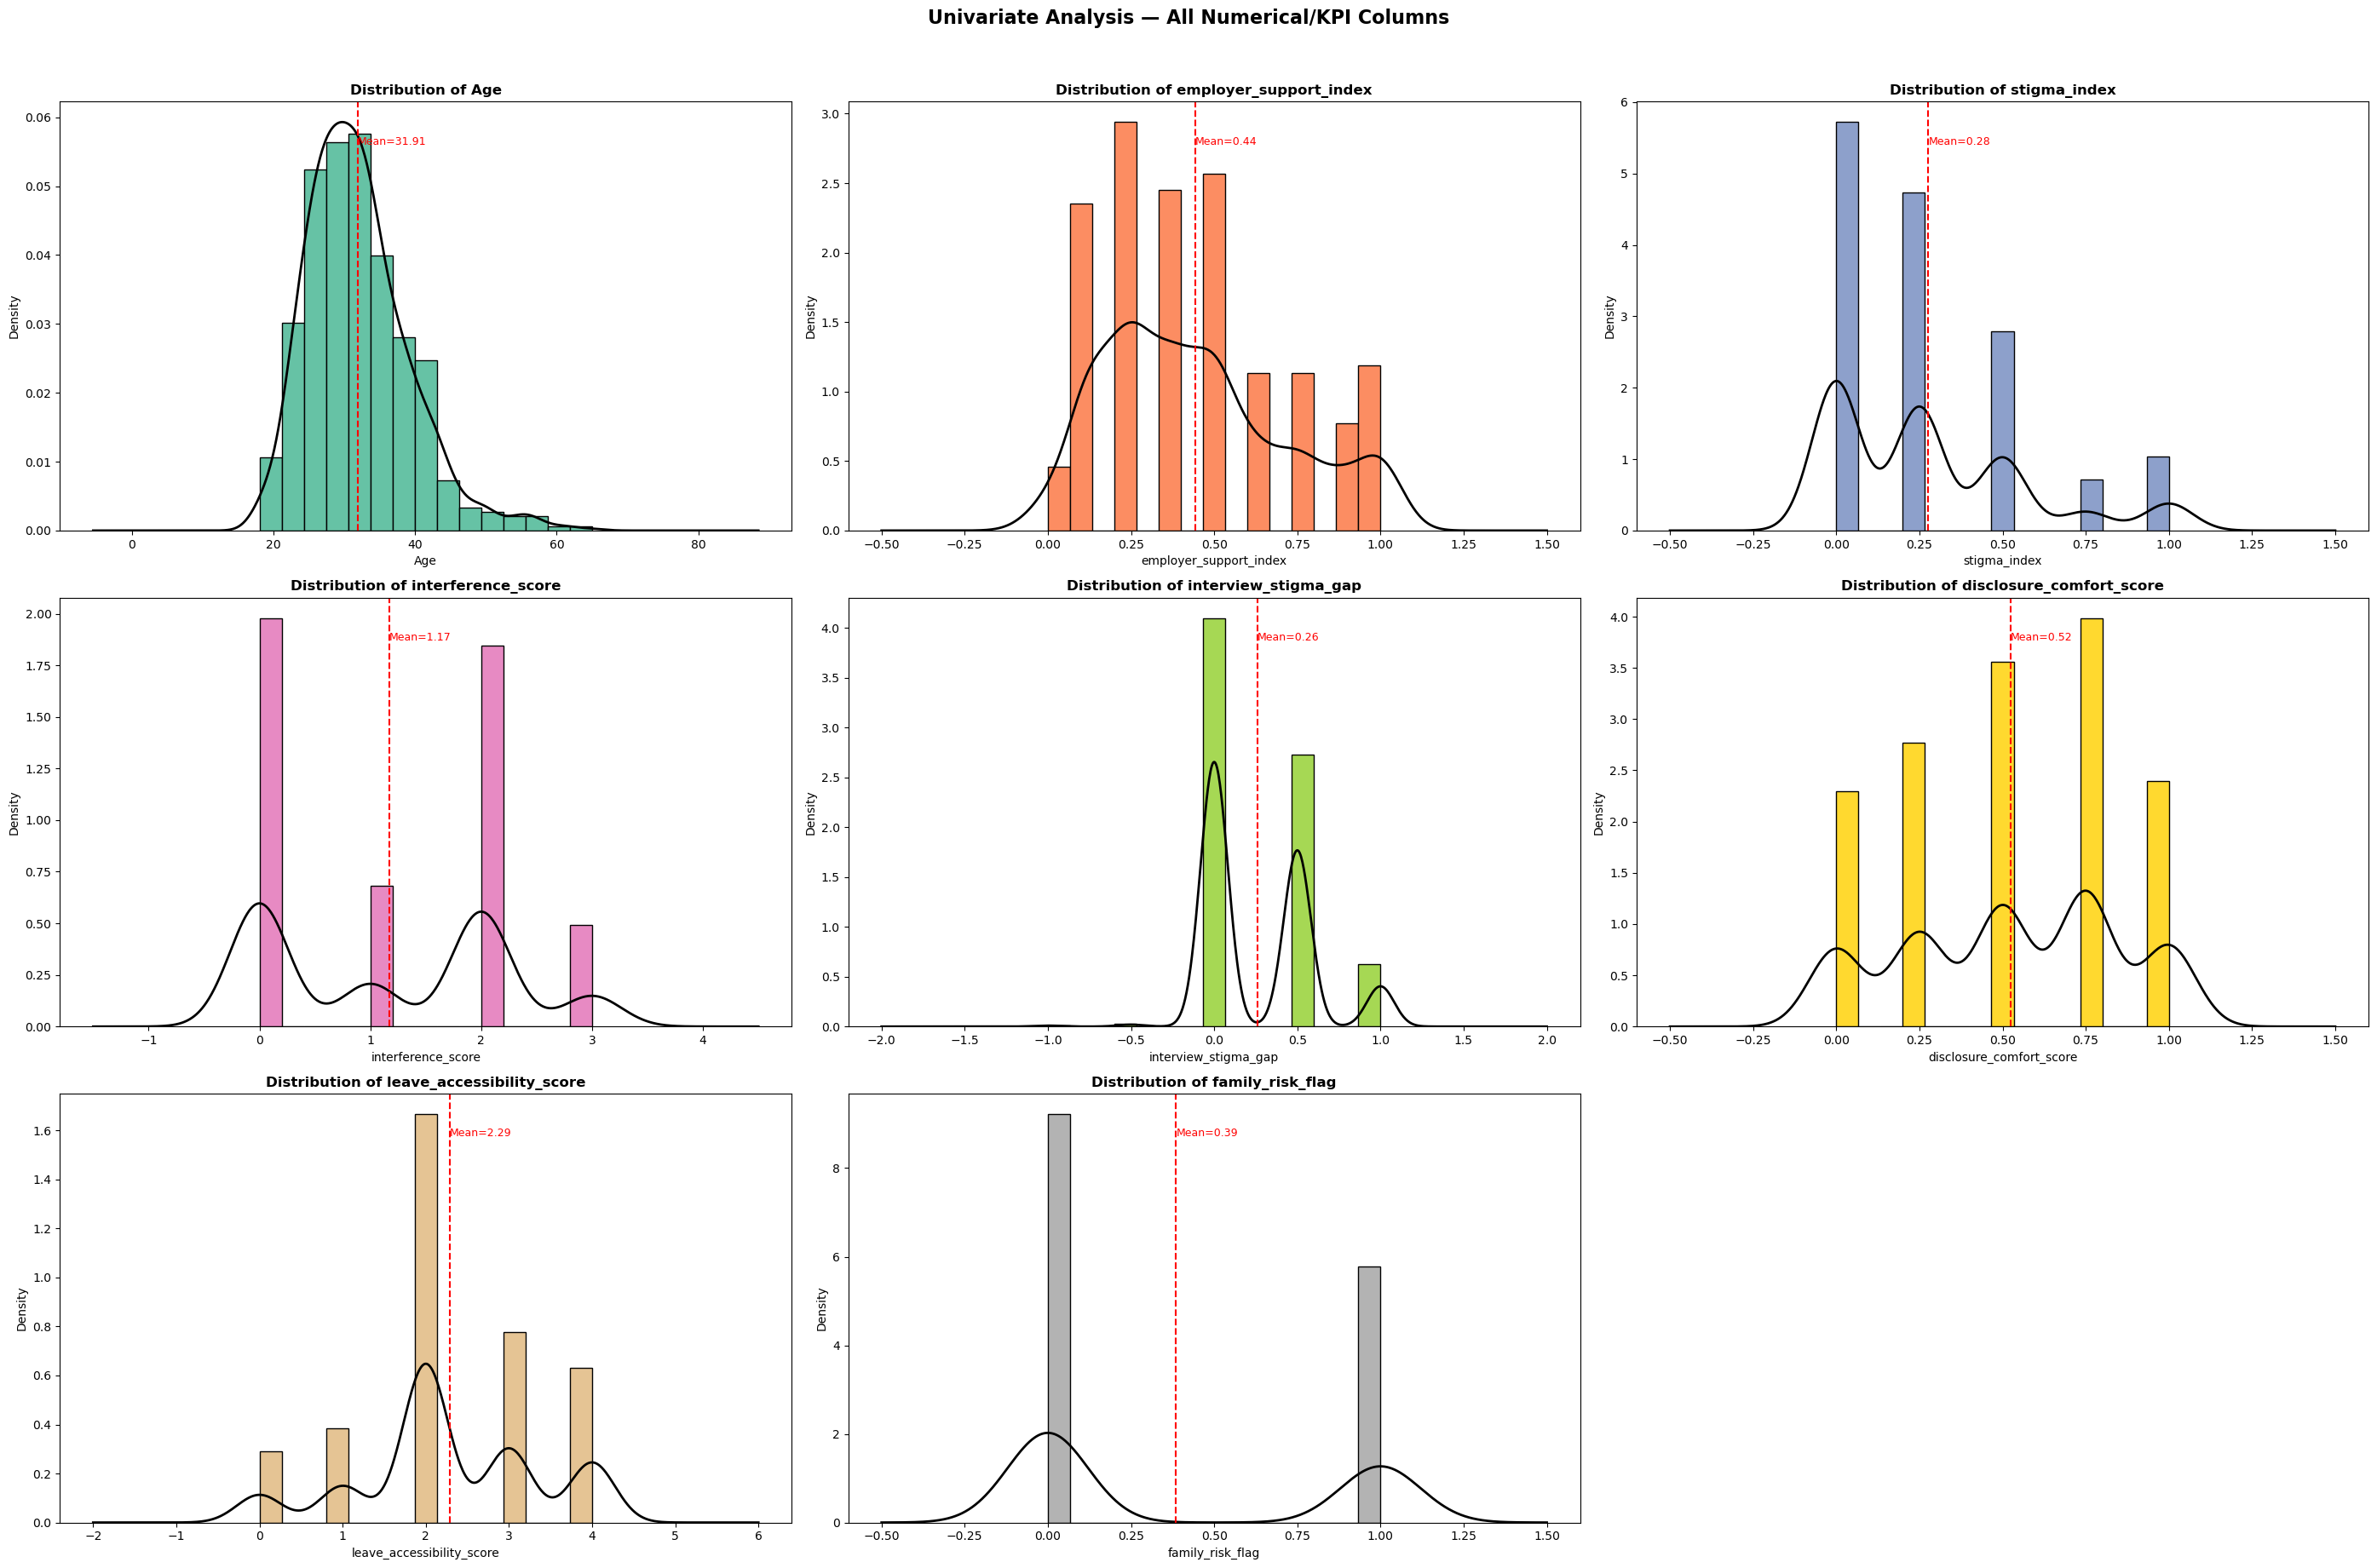

In [42]:
# All numerical KPI columns
num_cols = ['Age', 'employer_support_index', 'stigma_index', 
            'interference_score',
            'disclosure_comfort_score', 'leave_accessibility_score',
            'family_risk_flag']

n_cols = 3
n_rows = -(-len(num_cols) // n_cols)

# Change this line only
fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=15, 
                 color=sns.color_palette("Set2")[i % 8], 
                 edgecolor='black', density = True)
    df[col].dropna().plot.kde(ax=axes[i], color='black', linewidth=2)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)

    # Add mean line
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
    axes[i].text(mean_val, axes[i].get_ylim()[1] * 0.9, 
                 f'Mean={round(mean_val,2)}', color='red', fontsize=9)

for k in range(i + 1, len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Univariate Analysis — All Numerical/KPI Columns',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observations

- **Age** is concentrated mostly in the late 20s to mid 30s, with a slight right skew, showing that most respondents are relatively young.
- **Employer Support Index** is mostly in the low-to-mid range, suggesting that strong workplace support is not common across the dataset.
- **Stigma Index** is concentrated at lower values, which means most employees report low-to-moderate stigma, though a smaller group faces higher stigma.
- **Interference Score** is spread across multiple levels, showing that while many employees report low or moderate interference, a noticeable group experiences stronger work interference.
- **Interview Stigma Gap** is centered around lower-to-mid values, indicating some hesitation in discussing mental health compared to physical health.
- **Disclosure Comfort Score** is mostly around the middle range, suggesting mixed comfort in discussing mental health at work.
- **Leave Accessibility Score** is moderate overall, meaning leave access is not uniformly easy for all employees.
- **Family Risk Flag** shows that most employees do not report family history, but a substantial minority does, making it an important variable for later analysis.

# **2. Bivariate Analysis**

## **Bivariate Analysis Using Box Plots**

### **GROUP 1 - KPI Scores (0–1 Scale) vs Treatment**

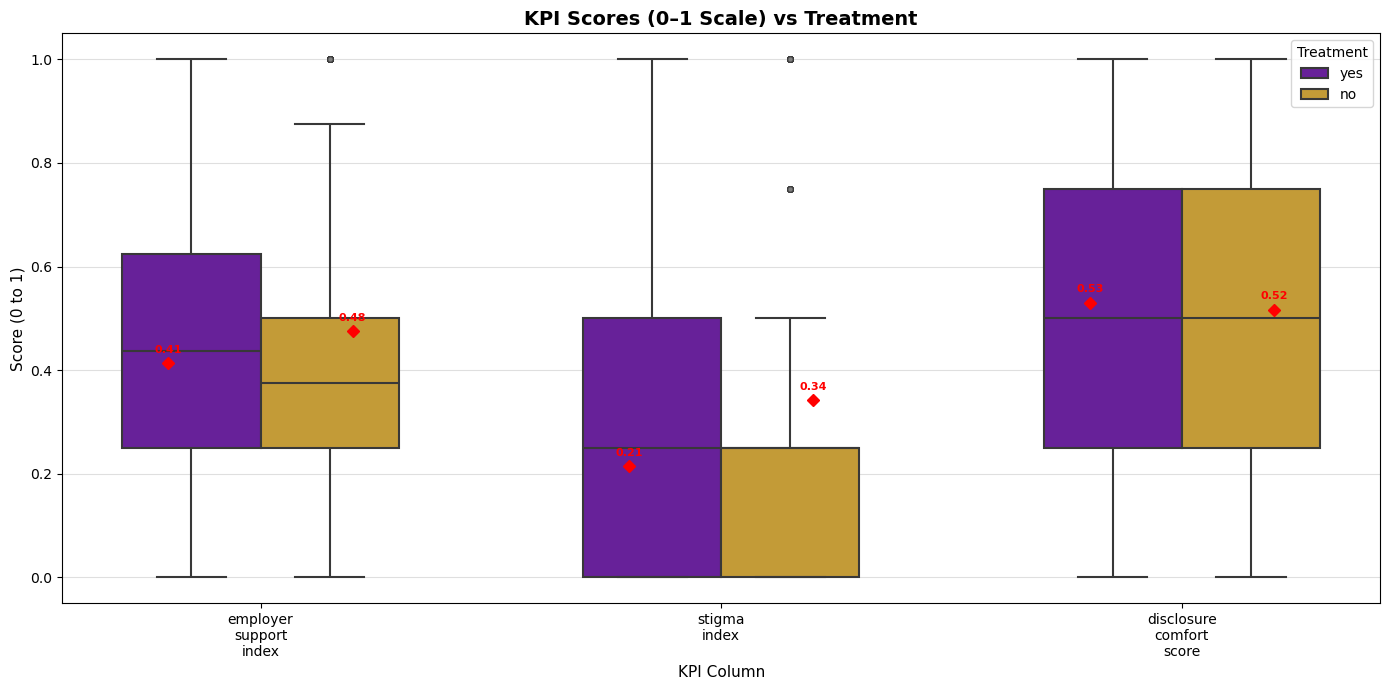

In [43]:
kpi_0_1 = ['employer_support_index', 'stigma_index', 
            'disclosure_comfort_score']

fig, ax = plt.subplots(figsize=(14, 7))

# Melt dataframe to long format for grouped boxplot
df_melt1 = df[kpi_0_1 + ['treatment']].melt(id_vars='treatment', var_name='KPI', value_name='Score')

sns.boxplot(data=df_melt1,x='KPI',y='Score',hue='treatment',palette=['#6A0DAD', '#DAA520'],width=0.6,linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5),ax=ax)

# Add mean markers
for j, kpi in enumerate(kpi_0_1):
    means = df.groupby('treatment')[kpi].mean()
    for k, (treat, mean_val) in enumerate(means.items()):
        offset = -0.2 if k == 0 else 0.2
        ax.plot(j + offset, mean_val, marker='D', 
                color='red', markersize=6, zorder=5)
        ax.text(j + offset, mean_val + 0.02, f'{mean_val:.2f}',
                ha='center', fontsize=8, color='red', fontweight='bold')

ax.set_title('KPI Scores (0–1 Scale) vs Treatment', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('KPI Column', fontsize=11)
ax.set_ylabel('Score (0 to 1)', fontsize=11)
ax.set_xticks(range(len(kpi_0_1)))
ax.set_xticklabels([col.replace('_', '\n') for col in kpi_0_1], fontsize=10)
ax.legend(title='Treatment', fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### Box Plot Insights: KPI Scores vs Treatment

- **Employer Support Index:** The treatment = yes group shows a slightly lower central tendency than the treatment = no group (mean: 0.41 vs 0.48). This suggests that employees who reported needing treatment tend to experience somewhat lower workplace support. However, the overlap between the two groups is still large, so employer support alone is not a perfect separator.

- **Stigma Index:** The treatment = yes group has a lower stigma score than the treatment = no group (mean: 0.21 vs 0.34). This suggests that employees who reported taking or needing treatment may be in relatively less stigma-prone environments, or may be more willing to seek help despite stigma. Therefore, this plot does **not** support the claim that higher stigma is directly linked with treatment = yes in this KPI comparison.

- **Disclosure Comfort Score:** The two groups are very similar (0.51 vs 0.52), with strong overlap in their distributions. This suggests that disclosure comfort, by itself, is not a strong standalone differentiator between treatment = yes and treatment = no in this dataset.

### **GROUP 2 - Interference & Leave Accessibility vs Treatment**

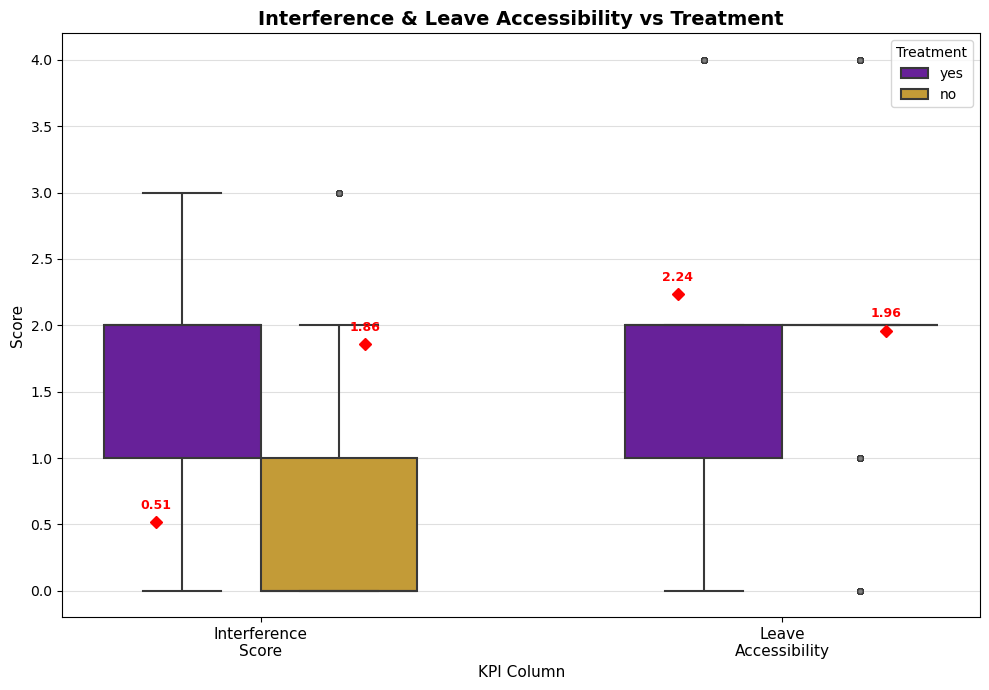

In [27]:
kpi_scores = ['interference_score', 'leave_accessibility_score']

fig, ax = plt.subplots(figsize=(10, 7))

df_melt3 = df[kpi_scores + ['treatment']].melt(id_vars='treatment',var_name='KPI',value_name='Score')

sns.boxplot(data=df_melt3,x='KPI',y='Score',hue='treatment',palette=['#6A0DAD', '#DAA520'],width=0.6,linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='gray',markersize=4, alpha=0.5),ax=ax)

# Mean markers
for j, kpi in enumerate(kpi_scores):
    means = df.groupby('treatment')[kpi].mean()
    for k, (treat, mean_val) in enumerate(means.items()):
        offset = -0.2 if k == 0 else 0.2
        ax.plot(j + offset, mean_val, marker='D',
                color='red', markersize=6, zorder=5)
        ax.text(j + offset, mean_val + 0.1, f'{mean_val:.2f}',
                ha='center', fontsize=9, color='red', fontweight='bold')

ax.set_title('Interference & Leave Accessibility vs Treatment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('KPI Column', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(range(len(kpi_scores)))
ax.set_xticklabels(['Interference\nScore', 'Leave\nAccessibility'], fontsize=11)
ax.legend(title='Treatment', fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

#### **Observations:**
#### - Interference score has the strongest split — treatment=yes mean=0.51 vs treatment=no mean=1.86, confirming work 
#### interference is the biggest driver of treatment need
#### - Leave accessibility is similar across both groups (2.24 vs 1.96) — ease of leave has weak influence on treatment need

## **3. Mulitvariate Analysis**

### - Mulitvariate Analysis Using Correlation Heatmap 

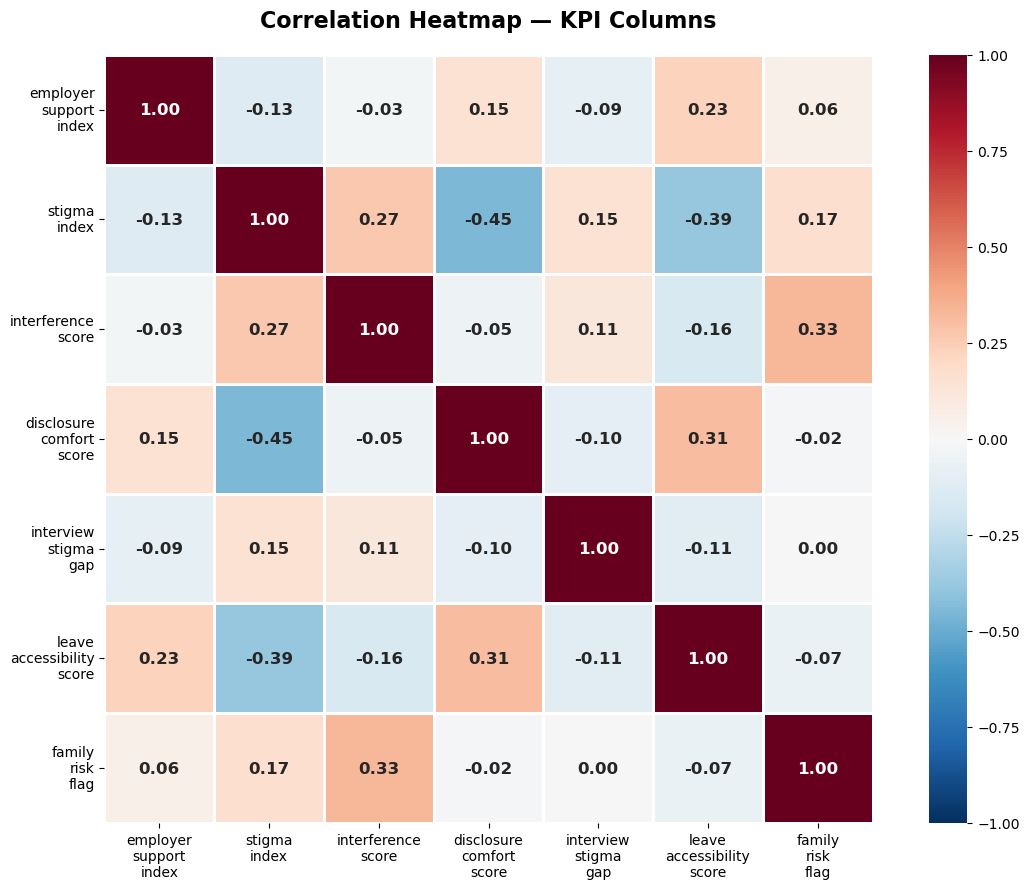

In [28]:
# KPI columns for correlation
kpi_cols = ['employer_support_index', 'stigma_index', 
            'interference_score', 'disclosure_comfort_score',
            'interview_stigma_gap', 'leave_accessibility_score',
            'family_risk_flag']

# Compute correlation matrix
corr_matrix = df[kpi_cols].corr().round(2)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='RdBu_r',center=0,linewidths=0.8,linecolor='white',square=True,
            annot_kws={'size': 12, 'weight': 'bold'},ax=ax,vmin=-1, vmax=1)

ax.set_title('Correlation Heatmap — KPI Columns',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(
    [col.replace('_', '\n') for col in kpi_cols],
    fontsize=10, rotation=0
)
ax.set_yticklabels(
    [col.replace('_', '\n') for col in kpi_cols],
    fontsize=10, rotation=0
)

plt.tight_layout()
plt.show()

#### **Observations:** 
#### - stigma_index vs disclosure_comfort_score = -0.45 
#### - strongest negative correlation — higher stigma means employees are less comfortable disclosing mental health
#### - stigma_index vs leave_accessibility_score = -0.39 → high stigma workplaces also make leave harder to access
#### - interference_score vs family_risk_flag = 0.33 → employees with family history experience more work interference
#### - employer_support_index vs leave_accessibility_score = 0.23 → supportive companies also provide easier leave access
#### - All other correlations are below 0.20 → no multicollinearity issue, each KPI measures a distinct dimension

## - Multi Variate Analysis using Pair Plot

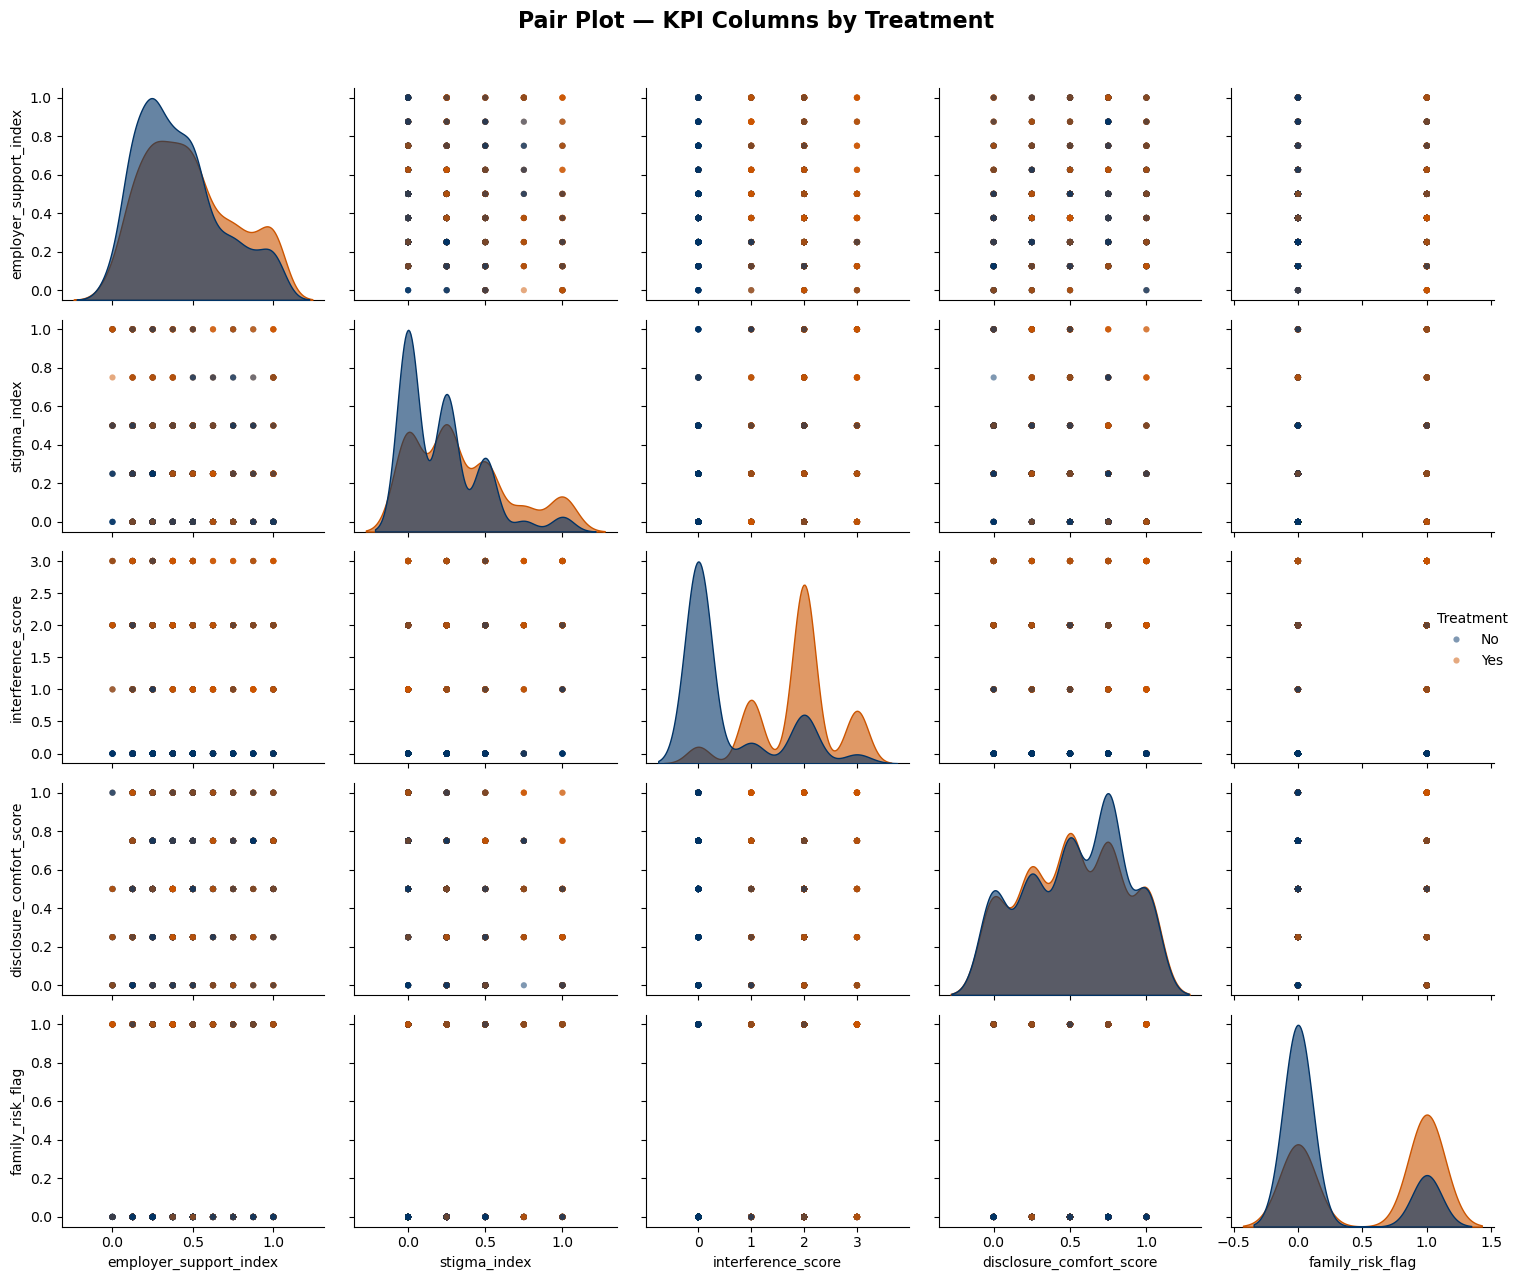

In [29]:
# Encode treatment as 0/1 for color mapping
df['treatment_encoded'] = df['treatment'].map({'yes': 1, 'no': 0})

pair_cols = ['employer_support_index', 'stigma_index',
             'interference_score', 'disclosure_comfort_score',
             'family_risk_flag', 'treatment_encoded']

pair_df = df[pair_cols].dropna()

g = sns.pairplot(pair_df,hue='treatment_encoded',palette={0: '#003366', 1: '#CC5500'},diag_kind='kde',
                 plot_kws=dict(alpha=0.5, edgecolor='none', s=20),diag_kws=dict(fill=True, alpha=0.6),height=2.5,aspect=1.1)

# Update legend labels
g._legend.set_title('Treatment')
for t, label in zip(g._legend.texts, ['No', 'Yes']):
    t.set_text(label)

g.figure.suptitle('Pair Plot — KPI Columns by Treatment',
                  fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Observations:**
 - interference_score KDE (diagonal) shows clearest separation — treatment=yes (orange) peaks at higher interference values confirming interference is the strongest predictor
 - family_risk_flag KDE shows treatment=yes group is visibly shifted toward 1.0 — family history strongly associated with treatment need
 - stigma_index KDE shows treatment=no group slightly higher — high stigma employees avoid seeking treatment
 - employer_support_index vs stigma_index scatter shows negative trend — low support companies have higher stigma
 - Most scatter plots show grid-like patterns due to discrete encoded KPI values — expected for categorical-origin data

# **4. Violin Plot**

#### A Violin plot combines a box plot and KDE into one — the width of the violin at any point shows
#### how many employees have that value (wider = more employees). The inner box shows median and 
#### IQR. This gives a complete picture of distribution shape, spread, and central tendency in one view.

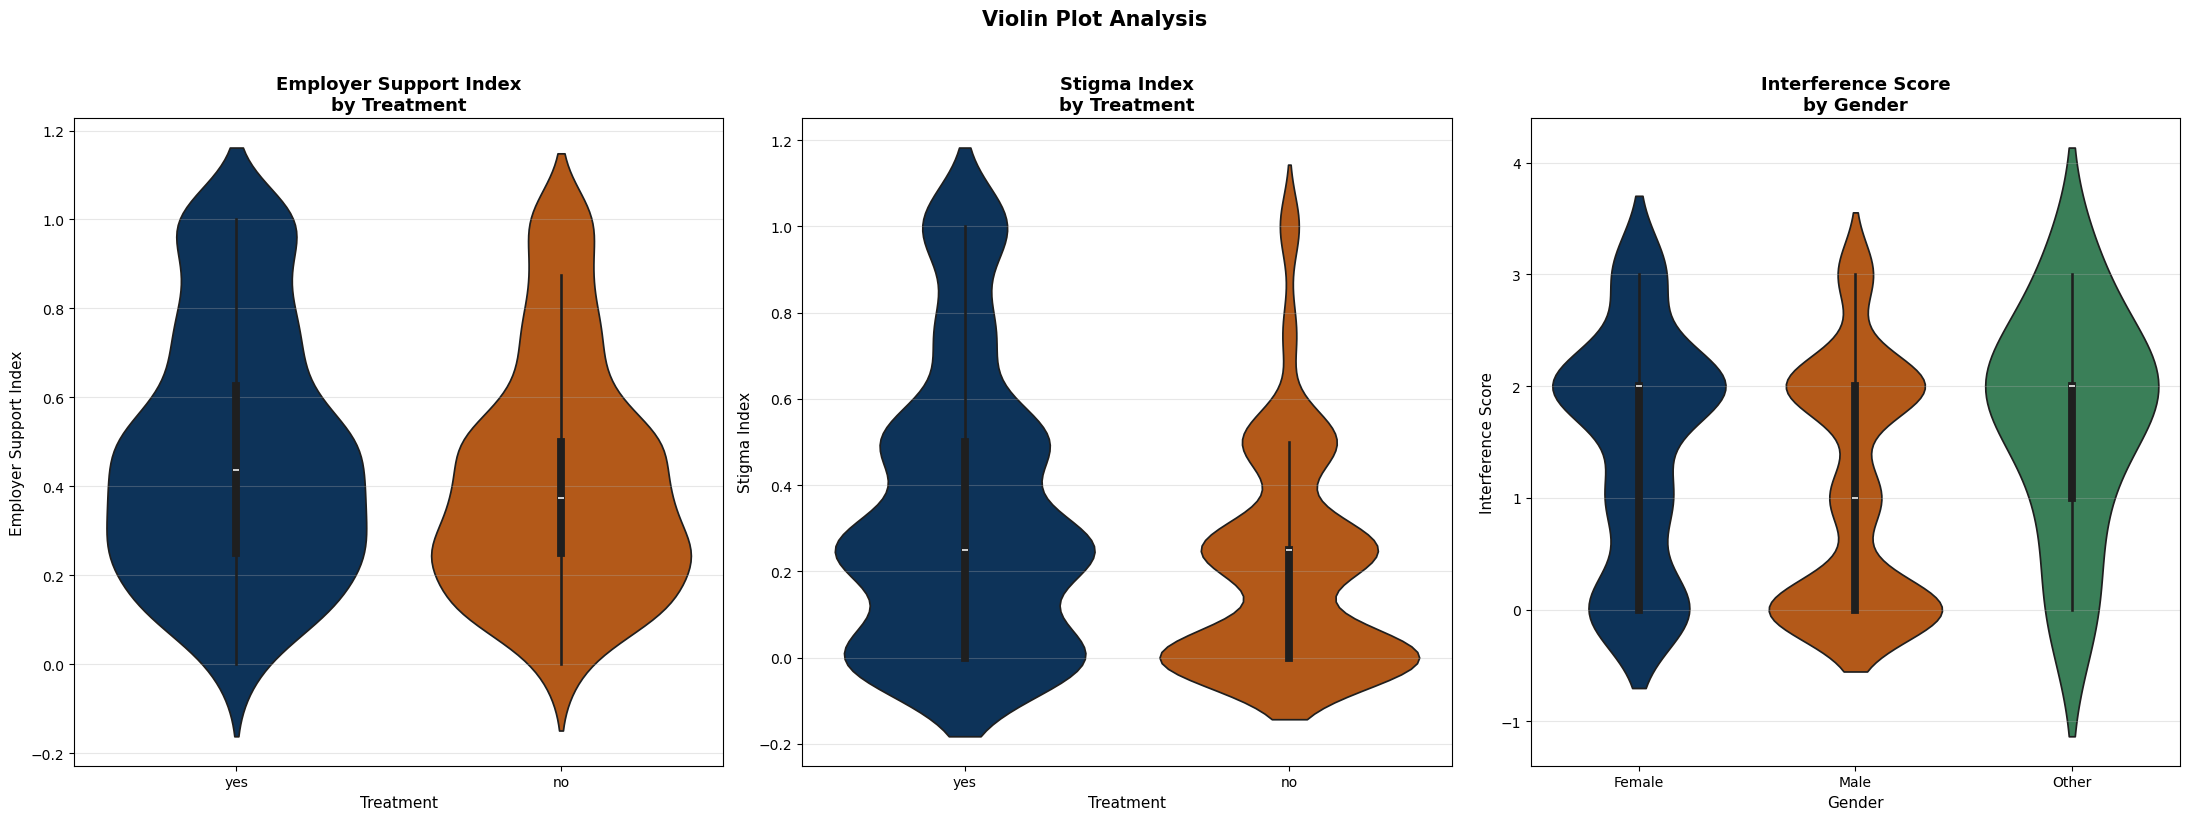

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Plot 1 — Employer Support vs Treatment
sns.violinplot(data=df,x='treatment',y='employer_support_index',hue='treatment',
               palette=['#003366', '#CC5500'],inner='box',legend=False,ax=axes[0])
axes[0].set_title('Employer Support Index\nby Treatment',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Treatment', fontsize=11)
axes[0].set_ylabel('Employer Support Index', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — Stigma Index vs Treatment
sns.violinplot(data=df,x='treatment',y='stigma_index',hue='treatment',
               palette=['#003366', '#CC5500'],inner='box',legend=False,ax=axes[1])
axes[1].set_title('Stigma Index\nby Treatment',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Treatment', fontsize=11)
axes[1].set_ylabel('Stigma Index', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3 — Gender vs Interference Score
sns.violinplot(data=df,x='Gender',y='interference_score',hue='Gender',
               palette=['#003366', '#CC5500', '#2E8B57'],inner='box',legend=False,ax=axes[2])
axes[2].set_title('Interference Score\nby Gender',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Gender', fontsize=11)
axes[2].set_ylabel('Interference Score', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Violin Plot Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Observations:**
##### - Employer support violin shows treatment=yes group has a wider spread at lower support values — confirming poor support is 
##### consistently linked to treatment need
##### - Stigma index violin shows treatment=no group has a heavier upper tail — high stigma employees cluster 
##### in the no-treatment group, proving stigma blocks treatment seeking
##### - Gender vs interference shows Male violin is wider at mid-range values (1-2) while Female violin shows 
##### more concentration at higher interference — females experience more intense work interference despite 
##### being a smaller group in the dataset

# **5. Stacked Bar**

## Work Interference vs Treatment — Stacked Bar

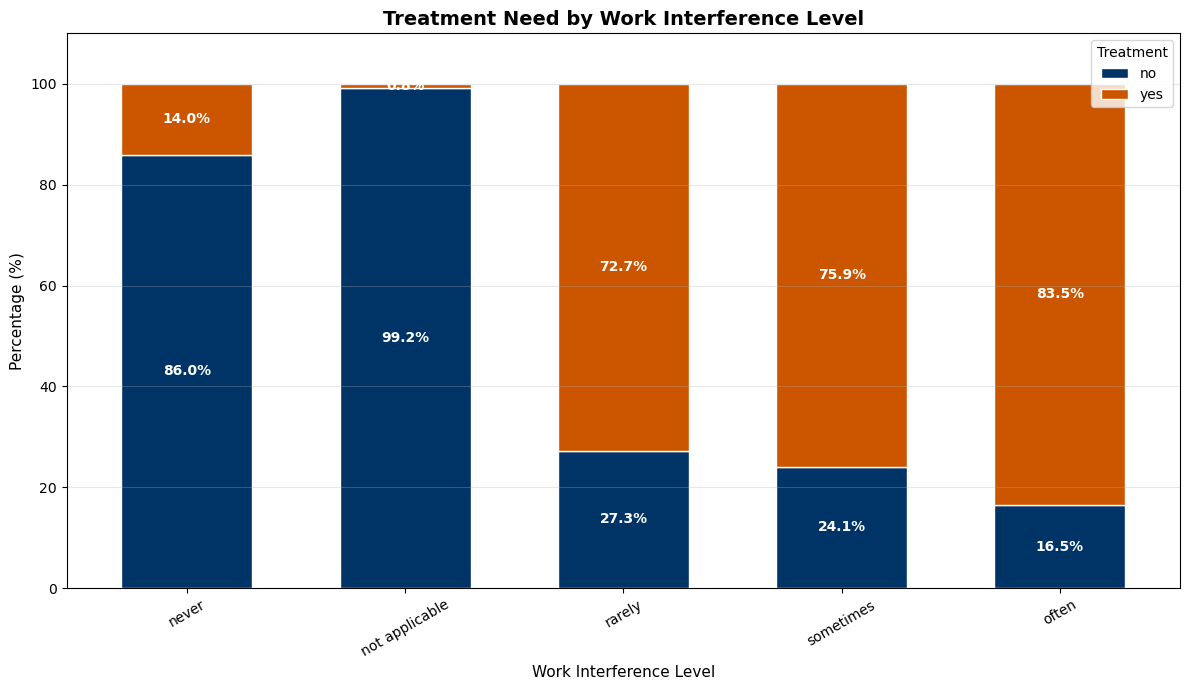

In [31]:
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate percentage breakdown
interfere_treat = df.groupby(['work_interfere', 'treatment']).size().unstack(fill_value=0)
interfere_treat_pct = interfere_treat.div(interfere_treat.sum(axis=1), axis=0) * 100

# Define order
order = ['never', 'not applicable', 'rarely', 'sometimes', 'often']
interfere_treat_pct = interfere_treat_pct.reindex(order)

interfere_treat_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#003366', '#CC5500'],
    edgecolor='white',
    width=0.6
)

# Add percentage labels inside bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', 
                 label_type='center', fontsize=10,
                 fontweight='bold', color='white')

ax.set_title('Treatment Need by Work Interference Level',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Work Interference Level', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(order, rotation=30, fontsize=10)
ax.legend(title='Treatment', fontsize=10)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **Observations:**
#### - 'Often' interference group has the highest treatment=yes rate — confirming severe interference strongly drives treatment seeking
#### - 'Never' group is almost entirely treatment=no — no interference means no treatment need
#### - 'Sometimes' group shows a near 50-50 split — moderate interference is the most at-risk undecided group
#### - 'Not applicable' group is overwhelmingly treatment=no — as expected, no condition means no treatment need

# Key Insights

Based on the analysis performed in this notebook, the following major insights were observed:

1. **Family history is a strong risk marker for treatment need.**  
Employees with a family history of mental health issues consistently show a stronger association with `treatment = yes`, making this one of the clearest personal risk factors in the dataset.

2. **Work interference is the strongest practical driver in the analysis.**  
Among all the factors studied, `work_interfere` shows the clearest separation between employees who reported needing treatment and those who did not. As work interference increases, the likelihood of treatment need also increases strongly.

3. **Difficulty in taking leave is linked to higher treatment need.**  
Employees who reported that taking leave for mental health reasons is difficult were more likely to fall into the treatment-needed group. This suggests that poor leave accessibility may act as a barrier to timely support.

4. **Stigma and fear of consequences are closely associated with treatment need.**  
Employees who fear negative consequences of discussing mental health, or who have observed negative outcomes for coworkers, show a stronger connection with treatment need. This indicates that workplace culture and perceived stigma play an important role.

5. **Lower employer support is associated with higher treatment need.**  
The KPI-based analysis shows that employees in the treatment-needed group generally experience lower employer support, weaker wellness-related communication, and less clarity around available help resources.

6. **Disclosure comfort is lower in more stigma-prone environments.**  
The multivariate and KPI analysis indicates that when stigma is higher, employees tend to feel less comfortable discussing mental health with coworkers, supervisors, or in professional settings such as interviews.

7. **Gender-based differences are visible, but must be interpreted carefully.**  
The notebook shows variation across gender categories in treatment-related patterns. However, the `Other` category has a very small number of observations, so conclusions for that group should be treated cautiously.

# Major Business Recommendations

#### Based on the analysis in this notebook, the following business recommendations are most likely to create meaningful impact:


#### 1. **Identify and support employees showing work interference early.**  
##### Work interference appears to be one of the clearest indicators linked with treatment need. Organizations should introduce regular wellness check-ins, manager observation frameworks, and early-support referrals so that employees can receive help before mental health issues begin affecting work more severely.

#### 2. **Reduce stigma through manager training and safe reporting channels.**  
##### Fear of negative consequences and low disclosure comfort are strongly associated with treatment need. The company should train managers on mental health conversations, strengthen anonymity/confidentiality practices, and provide anonymous help channels for employees who are not comfortable speaking openly.

#### 3. **Make mental health leave easier to access.**  
##### Employees with lower leave accessibility are more associated with treatment need. The company should simplify the leave process, clearly explain eligibility and steps, and create a confidential leave-request option so employees can seek help without hesitation.


# Final Verdict

#### Based on the analysis, employees most likely to report a need for mental health treatment are those showing stronger work interference, lower workplace support, greater difficulty around leave access, and responses linked with stigma or fear of consequences. Overall, the findings suggest that treatment need is associated not only with personal risk factors such as family history, but also with whether mental health problems are actively affecting work and whether the workplace feels supportive enough for employees to seek help.

# Limitations

Although the analysis provides useful insights, a few limitations should be noted:

- The survey data covers only a short time period, from **August 27, 2014 to August 29, 2014**, so the findings may not reflect longer-term workplace patterns.
- The dataset does not include important variables such as **workload, absenteeism, job satisfaction, or performance-related measures**, which limits deeper analysis of the causes behind treatment need.
- The findings in this notebook show **associations between factors and treatment need**, but they should not be interpreted as direct cause-and-effect relationships.